5350 Thesis in Economics

Andres Cruz 25199 & Klara Holmer 25037

Code for Generella Betygspoäng Analysis

In [1]:
# Importing Libraries
import numpy as np 
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

Gymnasieskola I - Avgångselever, nationella program läsår 2014/15 till 2023/24 

"Uppgifterna avser betyg utfärdade under det valda läsåret."

- Excel filerna är ordnade efter vårterminens år
- I dessa filer fördröjs inga dår eftersom vi är intresserade av avgångsresultaten

In [2]:
# Step 1 - Creating DataFrame_I

# --- Specify which program (i.e., which sheet_name) to read ---
program = "Högskoleförberedande program" 

# Printing program choice
print(f"Your choice was {program}")

Your choice was Högskoleförberedande program


In [289]:
# Step 1 - Creating DataFrame_I

# Define the folder path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/gymnasieskola_IIII'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of ACADEMIC_YEAR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending)
# Excel files are for the cohort finishing upper secondary school
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17', '2017/18', '2018/19','2019/20', '2020/21', '2021/22']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which upper secondary program to read. This is done in the chunk above
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row (index 8), Pandas DataFrame positioning
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 8
            column_names = temp_df.iloc[8].tolist()
            # Now read the data, skipping the first 9 rows from the excel file
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=9)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1)
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df['academic_year'] = ACADEMIC_YEAR[i] 

        # Add the "educational_stage" column with the fixed value 'gymnasieskola'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function, with specified program
Gymnasieskola_I = read_excel_files(program)

In [290]:
# Step 2  - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
new_names = [
    'school_name',                                               # Column 1: from 'Skola'
    'school_ID',                                                 # Column 2: from 'Skol-enhetskod'
    'school_municipality',                                       # Column 3: from 'Skolkommun'
    'municipality_ID',                                           # Column 4: from 'Kommun-kod'
    'type_of_ownership',                                         # Column 5: from 'Typ av huvudman'
    'owner',                                                     # Column 6: from 'Huvudman'
    'owner_orgnr',                                               # Column 7: from 'Huvudman orgnr'
    'graduating_students',                                       # Column 8: from 'Totalt antal' 
    'share_with_degree',                                         # Column 9: from 'Andel (%) med examen'
    'share_with_study_certificate',                              # Column 10: from 'Andel (%) med studiebevis'
    'share_with_basic_eligibility',                              # Column 11: from 'Andel (%) med grundl. behörighet'
    'share_with_extended_program',                               # Column 12: from 'Andel (%) med utökat prog.'
    'average_grade_points',                                      # Column 13: from 'GBP för elever med examen eller studiebevis'
    'AGP_students_with_study_certificate',                       # Column 14: from 'GBP för elever med examen'
    'share_students_A_E_eng',                                    # Column 15: from 'Eng 5'
    'share_students_A_E_history',                                # Column 16: from 'Historia 1'
    'share_students_A_E_physical_education',                     # Column 17: from 'Idrott 1'
    'share_students_A_E_ma',                                     # Column 18: from 'Ma 1'
    'share_students_A_E_natural_sciences',                       # Column 19: from 'Na 1'
    'share_students_A_E_religion',                               # Column 20: from 'Re 1'
    'share_students_A_E_social_studies',                         # Column 21: from 'Sam 1'
    'share_students_A_E_sv',                                     # Column 22: from 'Sv 1'
    'share_students_A_E_swedish_as_second_language',             # Column 23: from 'Sv andraspr. 1'
    'share_students_A_E_gymnarb',                                # Column 24: from 'Gymnarb.'
    'academic_year',                                             # Column 25: from 'läsår'
    'educational_stage'                                          # Column 26: from 'skolform'
    ]
    
# Assign the new column names based on their position
Gymnasieskola_I.columns = new_names

# Define the list of columns to drop
columns_to_drop = [
    'school_name', 'owner', 'owner_orgnr', 'share_with_degree', 'share_with_study_certificate', 
    'share_with_basic_eligibility', 'share_with_extended_program', 'AGP_students_with_study_certificate',
    'share_students_A_E_eng', 'share_students_A_E_history', 'share_students_A_E_physical_education',                     
    'share_students_A_E_ma', 'share_students_A_E_natural_sciences', 'share_students_A_E_religion',                             
    'share_students_A_E_social_studies', 'share_students_A_E_sv', 'share_students_A_E_swedish_as_second_language', 'share_students_A_E_gymnarb'                                
    ]

# Drop the specified columns
Gymnasieskola_I.drop(columns=columns_to_drop, axis=1, inplace=True)

# Replacing . and .. with np.nan in the AGP_DataFrame_I
Gymnasieskola_I.replace(['.', '..'], np.nan, inplace=True)

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_79331/2436878775.py:49: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Gymnasieskola_I.replace(['.', '..'], np.nan, inplace=True)


Gymnasieskola - Antal elever 2013/14 till 2021/22

"Uppgifterna avser oktober det valda året."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Antal Elever' är detsamma på höst- och vårterminen

In [291]:
# Step 1 - Creating Dataframe_II

# Setting the path to the correct folder 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/gymnasieskola_II'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify (at the end of this chunk) which sheet_name to read 
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index in Pandas DataFrame positioning
            column_names = temp_df.iloc[10].tolist()
            # Now read the data, skipping the first rows 11 (10+1 for excel file indexing) from the Excel File, 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=11)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "skolform" column with the fixed value 'gymnasieskola'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function to the program (i.e., sheet_name specified in the beginning of the code)
Gymnasieskola_II = read_excel_files(program)

In [292]:
# Step 2  - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                         # Column 1 'Skola'
    'school_ID',                           # Column 2 'Skol-enhetskod'
    'school_municipality',                 # Column 3 'Skolkommun'
    'municipality_ID',                     # Column 4 'Kommun-kod'
    'type_of_ownership',                   # Column 5 'Typ av huvudman'
    'owner',                               # Column 6 'Huvudman'
    'owner_orgnr',                         # Column 7 'Huvudman orgnr'
    'total_school_students',               # Column 8 'Antal elever' 
    'students_year1',                      # Column 9 'Antal elever skolår 1'
    'students_year2',                      # Column 10 'Antal elever skolår '2'
    'students_year3',                      # Column 11 'Antal elever skolår 3
    'share_female_students',               # Column 12 'Andel kvinnor (%)'
    'share_foreign_background',            # Column 13 'Andel m utl bakgr (%)'
    'share_postsecondary_parents',         # Column 14 'Andel m högutb föräldrar (%)'
    'academic_year',                       # Column 15 'läsår_vår'
    'educational_stage'                    # Column 16  'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name', 
    'owner',                               # Column 6 'Huvudman'
    'owner_orgnr',                         # Column 7 'Huvudman orgnr'
    'students_year1',                      # Column 9 'Antal elever skolår 1'
    'students_year2',                      # Column 10 'Antal elever skolår '2'
    'students_year3'                       # Column 11 'Antal elever skolår 3
    ]

# Assigning new column names
Gymnasieskola_II.columns = new_column_names 

# Dropping columns which will not be use
Gymnasieskola_II.drop(columns=columns_to_drop, axis=1, inplace=True)

# Creating school_size_category
bins = [1, 49, 99, 199, 299, 399, 499, 599, 699, 799, 899, np.inf]
labels = ["1-49", "50-99", "100-199", "200-299", "300-399", "400-499", "500-599", "600-699", "700-799", "800-899", "900+"]

# Create a new column with categorized school sizes
Gymnasieskola_II['school_size'] = pd.cut(Gymnasieskola_II['total_school_students'], bins=bins, labels=labels, right=True)

# Replacing . and .. with np.nan 
Gymnasieskola_II.replace(['.', '..'], np.nan, inplace=True)

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_school_students',  'school_size',
                'share_female_students', 'share_foreign_background', 'share_postsecondary_parents']

# Reorder the DataFrame
Gymnasieskola_II = Gymnasieskola_II[column_order]

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_79331/255506589.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Gymnasieskola_II.replace(['.', '..'], np.nan, inplace=True)


Gymnasieskola - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22 

"Statistiken avser anställda den 15 oktober valt läsår."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Personalstatistik med lärarlegitimation och behörighet' är detsamma på höst- och vårterminen

In [293]:
# Step 1 - Creating Dataframe_III

# etting the path 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/gymnasieskola_III'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which sheet name from the Excel file to read
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
            
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 9, Pandas DataFrame positioning
            column_names = temp_df.iloc[9].tolist()
            # Now read the data, skipping the first 10 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=10)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "läsår_vår" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "skolform" column with the fixed value 'upper secondary school'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function, with specified sheet name
Gymnasieskola_III = read_excel_files("Samtliga lärare" ) 

In [294]:
# Step 2  - Renaming columns and dropping columns

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                                            # Column 1 'Skola'
    'school_ID',                                              # Column 2 'Skol-enhetskod'
    'school_municipality',                                    # Column 3 'Skolkommun'
    'municipality_ID',                                        # Column 4 'Kommun-kod'
    'type_of_ownership',                                      # Column 5 'Typ av huvudman'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'total_fulltime_teachers',                                # Column 8 'Heltidstjänster Totalt antal'
    'total_fulltime_certified_teachers',                      # Column 9 'Heltidstjänster Antal med lärarlegitimation och behörighet'
    'share_fulltime_certified_teachers',                      # Column 10 'Heltidstjänster Andel med lärarlegitimation och behörighet'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'total_active_teachers',                                  # Column 12 'Tjänstgörande lärare Totalt antal '
    'total_active_certified_teachers',                        # Column 13 'Tjänstgörande lärare Antal med lärarlegitimation och behörighet i minst ett ämne'
    'share_active_certified_teachers',                        # Column 14 'Tjänstgörande lärare Andel med lärarlegitimation och behörighet i minst ett ämne'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    'academic_year',                                          # Column 16 'läsår'
    'educational_stage'                                       # Column 17 'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                            # Column 1 'Skola'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    ]

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers',            
                'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers']  

# Assigning new column names
Gymnasieskola_III.columns = new_column_names 

# Dropping columns which will not be used
Gymnasieskola_III.drop(columns=columns_to_drop, axis=1, inplace=True)

# Reorder the DataFrame
Gymnasieskola_III = Gymnasieskola_III[column_order]

Appending DataFrames

Gymnasieskola

- Gymnasieskola_I - Avgångselever, nationella program läsår 2016/17 till 2021/22 
- Gymnasieskola_II - Antal elever 2016/17 till 2021/22
- Gymnasieskola_III - Personalstatistik med lärarlegitimation och behörighet 2016/17 till 2021/22

In [295]:
#  Step 1 - Appending Gymnasieskola DataFrames 

# Define the join keys 
join_keys = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage']

# Merge the first two DataFrames with an left join and custom suffixes:
Gymnasieskola = pd.merge(Gymnasieskola_I, Gymnasieskola_II, on = join_keys, how = 'left')

# Merge the first two DataFrames with an inner join and custom suffixes:
Gymnasieskola = pd.merge(Gymnasieskola, Gymnasieskola_III, on = join_keys, how = 'left')

Grundskola - Slutbetyg årskurs 9, samtliga elever läsår 2014/15 till 2021/22

"Samtliga uppgifter utom totalen för antal elever, avser elever med betyg enligt det mål- och kunskapsrelaterade betygssystemet. Uppgifterna avser betyg före prövning."

- Spring semester year is used in the name of the ExcelFiles

In [296]:
# Step 1 - Slutbetyg årskurs 9 Grundskola - Creating Dataframe 

# Defining Path 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/grundskola_IIII'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify (at the end of this chunk) which sheet_name to read 
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index in Pandas DataFrame positioning
            column_names = temp_df.iloc[6].tolist()
            # Now read the data, skipping the first rows 7 (6+1 for excel file indexing) from the Excel File, 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=7)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "läsår_vår" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 'lower secondary school'
        df["educational_stage"] = 'grundskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# --- Specify sheet name choice ---
sheet_name_choice = "Statistik"

# Applying the function 
Grundskola_I = read_excel_files(sheet_name_choice)

In [297]:
# Step 2 - Modifying gpb_DataFrame_IIII

# Define a list of new column names in the correct order
new_names = [
    'school_name',                                  # Column 1: from 'Skola'
    'school_ID',                                    # Column 2: from 'Skol-enhetskod'
    'school_municipality',                          # Column 3: from 'Skolkommun'
    'municipality_ID',                              # Column 4: from 'Kommun-kod'
    'type_of_ownership',                            # Column 5: from 'Typ av huvudman'
    'owner',                                        # Column 6: from 'Huvudman'
    'owner_orgnr',                                  # Column 7: from 'Huvudman orgnr'
    'graduating_students',                          # Column 8: from 'Antal elever' 
    'andel_uppnått_kunskapskraven_i_alla_ämnen',    # Column 9: Andel som uppnått kunskapskraven i alla ämnen
    'andel_%_elever_behöriga_yrkesprog.',           # Column 10: Andel (%) elever behöriga till yrkesprog.
    'average_grade_points',                         # Column 11: Genomsnittligt meritvärde (17 ämnen)
    'academic_year',                                # Column 12: from 'läsår'
    'educational_stage'                             # Column 13: from 'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                           
    'owner',                                                  
    'owner_orgnr',                                            
    'andel_uppnått_kunskapskraven_i_alla_ämnen',                                    
    'andel_%_elever_behöriga_yrkesprog.',                                    
    ]
    
# Assign the new column names based on their position
Grundskola_I.columns = new_names

# Dropping columns which not be used 
Grundskola_I.drop(columns=columns_to_drop, axis=1, inplace=True)

# Filling in . and .. as np.nan (i.e., missing values)
Grundskola_I.replace(['.', '..'], np.nan, inplace=True)

# Genomsnittligt meritvärde (17 ämnen)
# Approximation to Gymnasieskolans Genomsnittligt Betygspoäng by divding by 17
antal_ämnen = 17 
Grundskola_I['average_grade_points'] = (Grundskola_I['average_grade_points'] / antal_ämnen).round(1)

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_79331/965177677.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Grundskola_I.replace(['.', '..'], np.nan, inplace=True)


Grundskola - Antal elever per årskurs 2012/13 till 2021/22 Skolenhet

"Uppgifterna avser oktober det valda året."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Antal Elever' är detsamma på höst- och vårterminen

In [298]:
# Step 1 - Antal Elever Grundskola - Creating Dataframe 

# Setting the path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/grundskola_II'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: Only sheet_name to read is Statistik
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 6, Pandas DataFrame positioning
            column_names = temp_df.iloc[6].tolist()
            # Now read the data, skipping the first 7 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=7)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 
        df["educational_stage"] = 'grundskola' 

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Creating DataFrame_II by using the function created 
Grundskola_II = read_excel_files('Statistik')

In [299]:
# Step 2 - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
# Column names for column number 10, 11, 12, and 13 are matched with Gymnasieskola DataFrames column names
new_names = [
    'school_name',                                             # Column 1 Skola 
    'school_ID',                                               # Column 2 Skol-enhetskod 
    'school_municipality',                                     # Column 3 Skolkommun 
    'municipality_ID',                                         # Column 4 Kommun-kod 
    'type_of_ownership',                                       # Column 5 Typ av huvudman 
    'owner',                                                   # Column 6 Huvudman
    'owner_orgnr',                                             # Column 7 Huvudman orgnr
    'student_nursery_school',                                  # Column 8 Elever, förskoleklass
    'share_female_students_nursery_school',                    # Column 9 Andel (%) flickor, förskoleklass
    'total_school_students',                                   # * Column 10 Elever, årskurs 1-9 
    'share_female_students',                                   # * Column 11 Andel (%) flickor, årskurs 1-9 
    'share_foreign_background',                                # * Column 12 Andel (%) elever med utländsk bakgrund, åk 1-9   
    'share_postsecondary_parents',                             # * Column 13 Andel (%) elever med föräldrar med eftergymnasial utb., åk 1-9   
    'students_year1',                                          # Column 14 Elever, årskurs 1
    'students_year2',                                          # Column 15 Elever, årskurs 2
    'students_year3',                                          # Column 16 Elever, årskurs 3
    'students_year4',                                          # Column 17 Elever, årskurs 4
    'students_year5',                                          # Column 18 Elever, årskurs 5
    'students_year6',                                          # Column 19 Elever, årskurs 6
    'students_year7',                                          # Column 20 Elever, årskurs 7
    'students_year8',                                          # Column 21 Elever, årskurs 8
    'students_year9',                                          # Column 22 Elever, årskurs 9
    'academic_year',                                           # Column 23 läsår
    'educational_stage'                                        # Column 24 skolform
    ]

# Applying the new names 
Grundskola_II.columns = new_names

# Define the list of columns to drop
columns_to_drop = ['school_name', 
                   'owner', 
                   'owner_orgnr',
                   'student_nursery_school', 
                   'share_female_students_nursery_school', 
                   'students_year1',                                         
                   'students_year2',            
                   'students_year3',                                          
                   'students_year4',                                          
                   'students_year5',     
                   'students_year6',                                         
                   'students_year7',            
                   'students_year8',                                          
                   'students_year9']

# Drop the specified columns
Grundskola_II.drop(columns=columns_to_drop, axis=1, inplace=True)

# Replacing . and .. with np.nan 
Grundskola_II.replace(['.', '..'], np.nan, inplace=True)

# Creating school_size_category
bins = [1, 49, 99, 199, 299, 399, 499, 599, 699, 799, 899, np.inf]
labels = ["1-49", "50-99", "100-199", "200-299", "300-399", "400-499", "500-599", "600-699", "700-799", "800-899", "900+"]

# Create a new column with categorized school sizes
Grundskola_II['school_size'] = pd.cut(Grundskola_II['total_school_students'], bins=bins, labels=labels, right=True)

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_school_students',  'school_size',
                'share_female_students', 'share_foreign_background', 'share_postsecondary_parents']

# Reorder the DataFrame
Grundskola_II = Grundskola_II[column_order]

print(Grundskola_I)

       school_ID school_municipality  municipality_ID type_of_ownership  \
0       71387206                 Ale             1440           Enskild   
1       48529699                 Ale             1440          Kommunal   
2       11043800                 Ale             1440          Kommunal   
3       61084420                 Ale             1440          Kommunal   
4       74064638            Alingsås             1489          Kommunal   
...          ...                 ...              ...               ...   
13386   50308658           Överkalix             2513          Kommunal   
13387   13342436           Överkalix             2513           Enskild   
13388   46252858          Övertorneå             2518           Enskild   
13389   90707437          Övertorneå             2518          Kommunal   
13390   18991431          Övertorneå             2518          Kommunal   

       graduating_students  average_grade_points academic_year  \
0                     42.0       

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_79331/2865765972.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Grundskola_II.replace(['.', '..'], np.nan, inplace=True)


Grundskola - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22

"Statistiken avser anställda den 15 oktober valt läsår."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Personalstatistik med lärarlegitimation och behörighet' är detsamma på höst- och vårterminen

In [300]:
# Step 1 - Creating Dataframe

# Setting path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/grundskola_III'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function 
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which sheet_name to read
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 9, Pandas DataFrame positioning
            column_names = temp_df.iloc[8].tolist()
            # Now read the data, skipping the first 10 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=9)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 'grundskola'
        df["educational_stage"] = 'grundskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function to each specific program
Grundskola_III = read_excel_files('Statistik')

In [301]:
# Step 2  - Renaming columns and dropping columns

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                                            # Column 1 'Skola'
    'school_ID',                                              # Column 2 'Skol-enhetskod'
    'school_municipality',                                    # Column 3 'Skolkommun'
    'municipality_ID',                                        # Column 4 'Kommun-kod'
    'type_of_ownership',                                      # Column 5 'Typ av huvudman'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'total_fulltime_teachers',                                # Column 8 'Heltidstjänster Totalt antal'
    'total_fulltime_certified_teachers',                      # Column 9 'Heltidstjänster Antal med lärarlegitimation och behörighet'
    'share_fulltime_certified_teachers',                      # Column 10 'Heltidstjänster Andel med lärarlegitimation och behörighet'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'total_active_teachers',                                  # Column 12 'Tjänstgörande lärare Totalt antal '
    'total_active_certified_teachers',                        # Column 13 'Tjänstgörande lärare Antal med lärarlegitimation och behörighet i minst ett ämne'
    'share_active_certified_teachers',                        # Column 14 'Tjänstgörande lärare Andel med lärarlegitimation och behörighet i minst ett ämne'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    'academic_year',                                          # Column 16 'läsår'
    'educational_stage'                                       # Column 17 'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                            # Column 1 'Skola'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    ]

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers',            
                'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers']  

# Assigning new column names
Grundskola_III.columns = new_column_names 

# Dropping columns which will not be used
Grundskola_III.drop(columns=columns_to_drop, axis=1, inplace=True)

# Reorder the DataFrame
Grundskola_III = Grundskola_III[column_order]

Appending DataFrames

Grundskola 

- Grundskola_I - Slutbetyg årskurs 9, samtliga elever läsår 2014/15 till 2023/24 
- Grundskola_II - Antal elever per årskurs 2012/13 till 2021/22 Skolenhet
- Grundskola_III - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22

In [302]:
#  Step 1 - Appending Grundskola DataFrames

# Merge the first two DataFrames with an left join and custom suffixes:
Grundskola = pd.merge(Grundskola_I, Grundskola_II, on = join_keys, how = 'left')

# Merge the first two DataFrames with an inner join and custom suffixes:
Grundskola = pd.merge(Grundskola, Grundskola_III, on = join_keys, how = 'left')

Concatenating Grundskola with Gymnasieskola

In [303]:
# Step 1 - Concatenating DataFrames
school_data_betyg = pd.concat([Gymnasieskola, Grundskola], ignore_index=True)

In [304]:
# Step 2 -  Adding County ID 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/kommun_I/georef-sweden-kommun.xlsx'

# Read all sheets at once into a dictionary
kommun_data = pd.read_excel(pathname, sheet_name=0)

# List of new names 
new_names = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'county_ID',            # Column 4 Län code
    'school_county',        # Column 5 Län name
    'municipality_ID',      # Column 6 Kommun code
    'school_municipality',  # Column 7 Kommun name
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# List of new names 
columns_to_drop = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# Applying the new names 
kommun_data.columns = new_names

# Drop the specified columns
kommun_data.drop(columns=columns_to_drop, axis=1, inplace=True)

# Define the join keys
join_keys = ['school_municipality', 'municipality_ID']

# Apply merging and store the results back in the list
school_data_betyg = pd.merge(school_data_betyg, kommun_data, on=join_keys, how='left') 

# Exporting
# Defining the full path where the Excel file will be saved
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/school_data_betyg.xlsx'

# Exporting all the tables created into one Excel File 
with pd.ExcelWriter(pathname) as writer:
    school_data_betyg.to_excel(writer, sheet_name = 'Betyg', index=False)

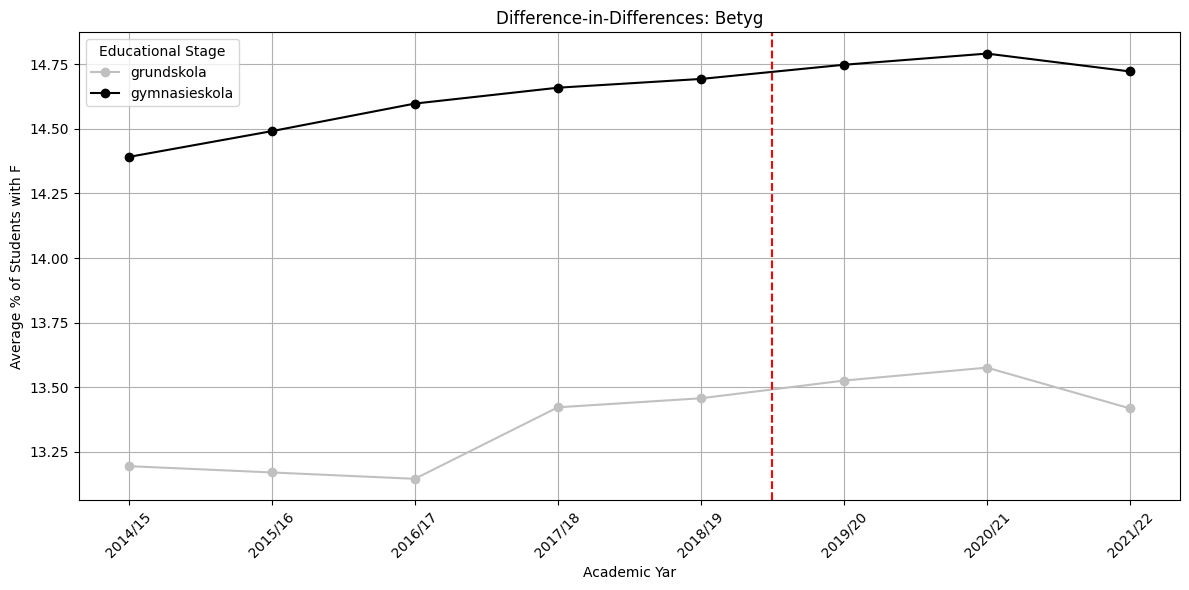

In [305]:
# Step 1 - Difference-in-Difference Plots


def process_and_plot_did(data, variable, title, treatment_year=19.5):
    """
    Processes the dataset, ensuring all years are represented, and generates a Difference-in-Differences plot.
    
    Parameters:
    - data: Pandas DataFrame containing the data. It must include a 'läsår' column with string values in the format 'yyyy/yy'.
    - variable: Column name for the dependent variable to be plotted.
    - title: Title for the plot.
    - treatment_year: The numeric part (yy) of the läsår when the treatment/intervention occurred.
    """
    
    # Create a numeric version of 'academic_year' using the yy part
    data['year_numeric'] = data['academic_year'].apply(lambda x: int(x.split('/')[1]))
    
    # Aggregate data by year_numeric, academic_year, and school type (educational_stage)
    grouped_df = data.groupby(['year_numeric', 'academic_year', 'educational_stage'], as_index=False)[variable].mean()
    
    # Create a full range of numeric years for continuity in the plot
    all_years = pd.DataFrame({
        'year_numeric': range(grouped_df['year_numeric'].min(), grouped_df['year_numeric'].max() + 1)
    })
    
    # Create a mapping from numeric year to academic_year using available data
    mapping = dict(zip(grouped_df['year_numeric'], grouped_df['academic_year']))
    
    # Generate the plot
    plt.figure(figsize=(12, 6))
    
    for educational_stage, subset in grouped_df.groupby('educational_stage'):
        # Merge with all_years to fill in any missing years
        subset = all_years.merge(subset, on='year_numeric', how='left')
        subset['educational_stage'] = educational_stage  # preserve educational_stage
        
        # Assign colors: blue for gymnasieskola, green for grundskola
        if educational_stage.lower() == 'gymnasieskola':
            color = 'black'
        elif educational_stage.lower() == 'grundskola':
            color = 'silver'
        else:
            color = None  # default color for any other skolform
        
        # Plot using the numeric year for the x-axis
        plt.plot(subset['year_numeric'], subset[variable], marker='o', linestyle='-', label=educational_stage, color=color)
    
    # Add a vertical line indicating the treatment year
    plt.axvline(x=treatment_year, color='red', linestyle='--')
    
    # Set custom x-ticks: use the numeric years but label them with the läsår format.
    xticks = all_years['year_numeric']
    xlabels = [mapping.get(x, f"{2000 + x - 1}/{x:02d}") for x in xticks]
    plt.xticks(xticks, xlabels, rotation=45)
    
    # Configure the plot
    plt.title(f'Difference-in-Differences: {title}')
    plt.xlabel('Academic Yar')
    plt.ylabel('Average % of Students with F')
    plt.legend(title='Educational Stage')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Apply the function to the provided dataframes
process_and_plot_did(school_data_betyg, 'average_grade_points', 'Betyg')
